In [1]:
import os
import pickle
from utils.plots import get_clause_lengths_by_polarity, plot_clause_length_boxplot_by_polarity, plot_literal_clause_frequency
import matplotlib.pyplot as plt
import numpy as np
import config
from utils.statistics import compute_clause_length_statistics, run_mannwhitney_pos_neg_length, run_kruskalwallis_across_specialists, run_posthoc_mannwhitney

In [2]:
CURRENT_DATASET = config.BREASTMNIST

In [3]:
canny_path = os.path.join("saved_models", "BreastMNIST_Canny_Specialist.pkl")
with open(canny_path, "rb") as f:
    tm_canny = pickle.load(f)
    

tm_gaussian = os.path.join("saved_models", "BreastMNIST_Adaptive_Gaussian_Specialist.pkl")
with open(tm_gaussian, "rb") as f:
    tm_gaussian = pickle.load(f)

tn_mean = os.path.join("saved_models", "BreastMNIST_Adaptive_Mean_Specialist.pkl") 
with open(tn_mean, "rb") as f:
    tm_mean = pickle.load(f)

tm_otsu = os.path.join("saved_models", "BreastMNIST_Otsu_Specialist.pkl")
with open(tm_otsu, "rb") as f:
    tm_otsu = pickle.load(f)

tm_thermo = os.path.join("saved_models", "BreastMNIST_Color_Thermometers_Specialist.pkl")
with open(tm_thermo, "rb") as f:
    tm_thermo = pickle.load(f)

In [4]:
specialists = {
    'Canny': tm_canny,
    'Ad. Gaussian': tm_gaussian,
    'Ad. Mean': tm_mean,
    'Otsu': tm_otsu,
    'Thermometer': tm_thermo,
}

In [5]:
for name, tm in specialists.items():
   print(f"========={name}")
   print(f"Number of Clauses for: {tm.number_of_clauses}")
   print(f"The Patch size is {tm.patch_dim}")
   print(f"The T value is {tm.T}")
   print(f"The s value is {tm.s}")
   print(f"The max included literals is {tm.max_included_literals}")
   print()

=========Canny
Number of Clauses for: 4000
The Patch size is (7, 7)
The T value is 3500
The s value is 15.0
The max included literals is 32

=========Ad. Gaussian
Number of Clauses for: 4000
The Patch size is (7, 7)
The T value is 7500
The s value is 4.0
The max included literals is 32

=========Ad. Mean
Number of Clauses for: 4000
The Patch size is (9, 9)
The T value is 7500
The s value is 5.0
The max included literals is 32

=========Otsu
Number of Clauses for: 4000
The Patch size is (9, 9)
The T value is 1500
The s value is 12.0
The max included literals is 128

=========Thermometer
Number of Clauses for: 4000
The Patch size is (7, 7)
The T value is 10000
The s value is 1.0
The max included literals is 64




--- Clause Length Observations: BreastMNIST | Class 0 ---
  Canny                     Positive:   2000  |  Negative:   2000
  Ad. Gaussian              Positive:   2000  |  Negative:   2000
  Ad. Mean                  Positive:   2000  |  Negative:   2000
  Otsu                      Positive:   2000  |  Negative:   2000
  Thermometer               Positive:   2000  |  Negative:   2000
------------------------------------------------------------
Saved to clause_analysis_plots/breast_clause_length_boxplot_class_0.svg


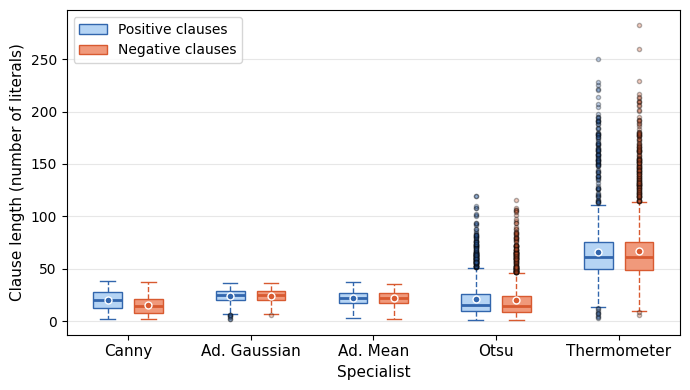


--- Clause Length Observations: BreastMNIST | Class 1 ---
  Canny                     Positive:   2000  |  Negative:   2000
  Ad. Gaussian              Positive:   2000  |  Negative:   2000
  Ad. Mean                  Positive:   2000  |  Negative:   2000
  Otsu                      Positive:   2000  |  Negative:   2000
  Thermometer               Positive:   2000  |  Negative:   2000
------------------------------------------------------------
Saved to clause_analysis_plots/breast_clause_length_boxplot_class_1.svg


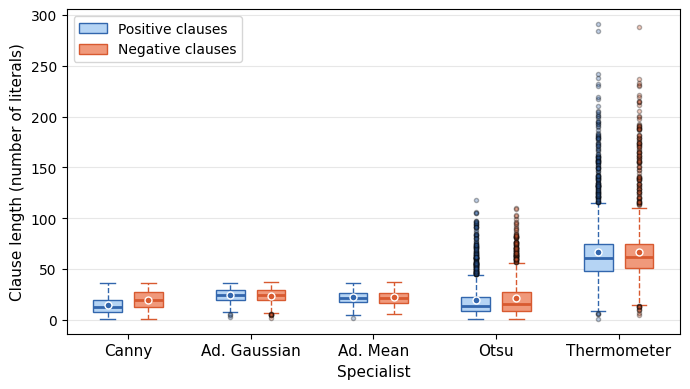

In [6]:
for target_class in [0, 1]:
    data_pos = {}
    data_neg = {}
    for name, tm in specialists.items():
        pos, neg = get_clause_lengths_by_polarity(tm, target_class)
        data_pos[name] = pos
        data_neg[name] = neg

    plot_clause_length_boxplot_by_polarity(
        data_pos, data_neg,
        target_class=target_class,
        figsize=(7, 4), 
        save_path=os.path.join("clause_analysis_plots", f"{CURRENT_DATASET}_clause_length_boxplot_class_{target_class}.svg")
    )

In [7]:
for target_class in [0, 1]:
    data_pos = {}
    data_neg = {}
    for name, tm in specialists.items():
        pos, neg = get_clause_lengths_by_polarity(tm, target_class)
        data_pos[name] = pos
        data_neg[name] = neg
    compute_clause_length_statistics(data_pos, data_neg, dataset_name='BreastMNIST', target_class=target_class)


Clause Length Statistics | BreastMNIST | Class 0
  Specialist                Polarity          n       Mean     Median        Std
  ------------------------- ------------ ------ ---------- ---------- ----------
  Canny                     Positive       2000      19.74      20.00       8.96
                            Negative       2000      15.04      14.00       8.33
  ------------------------- ------------ ------ ---------- ---------- ----------
  Ad. Gaussian              Positive       2000      23.96      25.00       6.18
                            Negative       2000      24.31      25.00       6.11
  ------------------------- ------------ ------ ---------- ---------- ----------
  Ad. Mean                  Positive       2000      22.25      22.00       6.32
                            Negative       2000      22.02      22.00       6.00
  ------------------------- ------------ ------ ---------- ---------- ----------
  Otsu                      Positive       2000      21.18 

In [8]:
for target_class in [0, 1]:
    data_pos = {}
    data_neg = {}  # make sure these are reset inside the loop
    for name, tm in specialists.items():
        pos, neg = get_clause_lengths_by_polarity(tm, target_class)
        data_pos[name] = pos
        data_neg[name] = neg
    run_mannwhitney_pos_neg_length(data_pos, data_neg, target_class=target_class)


Mann-Whitney U — Positive vs Negative Clause Lengths
Dataset: BreastMNIST | Class 0
H0: Positive and negative clause length distributions are identical.
H1: Positive and negative clause length distributions differ.

  Specialist                 n_pos  n_neg     U-stat      p-value   Effect (r)  Reject H0
  ------------------------- ------ ------ ---------- ------------ ------------ ----------
  Canny                       2000   2000  2601250.5     5.77e-61      -0.3006          ✓
  Ad. Gaussian                2000   2000  1936912.0        0.084       0.0315          ✗
  Ad. Mean                    2000   2000  2052266.5        0.152      -0.0261          ✗
  Otsu                        2000   2000  2095936.0        0.009      -0.0480          ✓
  Thermometer                 2000   2000  2020599.5        0.573      -0.0103          ✗

  Significance level: α = 0.05


Mann-Whitney U — Positive vs Negative Clause Lengths
Dataset: BreastMNIST | Class 1
H0: Positive and negative clause le

In [9]:
for target_class in [0, 1]:
    data_pos = {}
    data_neg = {}
    for name, tm in specialists.items():
        pos, neg = get_clause_lengths_by_polarity(tm, target_class)
        data_pos[name] = pos
        data_neg[name] = neg

    run_kruskalwallis_across_specialists(
        data_pos, data_neg,
        dataset_name='BreastMNIST',
        target_class=target_class
    )


Kruskal-Wallis — Clause Lengths Across Specialists
Dataset: BreastMNIST | Class 0
H0: Clause length distributions are identical across all specialists.
H1: At least one specialist has a different clause length distribution.

  Polarity      H-statistic      p-value  Reject H0
  ------------ ------------ ------------ ----------
  Positive        4414.1083       0.0000          ✓
  Negative        5135.0138       0.0000          ✓

  Significance level: α = 0.05


Kruskal-Wallis — Clause Lengths Across Specialists
Dataset: BreastMNIST | Class 1
H0: Clause length distributions are identical across all specialists.
H1: At least one specialist has a different clause length distribution.

  Polarity      H-statistic      p-value  Reject H0
  ------------ ------------ ------------ ----------
  Positive        5268.1382       0.0000          ✓
  Negative        4407.7187       0.0000          ✓

  Significance level: α = 0.05



In [10]:
for target_class in [0, 1]:
    data_pos = {}
    data_neg = {}
    for name, tm in specialists.items():
        pos, neg = get_clause_lengths_by_polarity(tm, target_class)
        data_pos[name] = pos
        data_neg[name] = neg
    run_posthoc_mannwhitney(
        data_pos, data_neg,
        dataset_name='BreastMNIST',
        target_class=target_class
    )  



Post-hoc Pairwise Mann-Whitney U — Across Specialists
Dataset: BreastMNIST | Class 0
H0: Clause length distributions are identical for a given pair of specialists.
H1: Clause length distributions differ for a given pair of specialists.

--- Positive clauses ---
  Pair                                              U-stat        p-value   Effect (r)  Reject H0
  --------------------------------------------- ---------- -------------- ------------ ----------
  Canny vs Ad. Gaussian                          1468562.5       4.82e-48       0.2657          ✓
  Canny vs Ad. Mean                              1698512.0       1.44e-16       0.1507          ✓
  Canny vs Otsu                                  2214231.5       4.39e-09      -0.1071          ✓
  Canny vs Thermometer                             95613.5       0.00e+00       0.9522          ✓
  Ad. Gaussian vs Ad. Mean                       2319120.0       2.18e-18      -0.1596          ✓
  Ad. Gaussian vs Otsu                           27